# CareerMatch AI — AI-Powered Resume Classification & Job Matching System

## Problem Statement

Recruiters and job seekers often face difficulty in quickly identifying whether a resume is suitable for a particular job role. Manually reviewing resumes is time-consuming, subjective, and difficult to scale when dealing with a large number of applications.

The objective of this project is to develop an AI-powered resume intelligence system that can process resume text, identify relevant skills and keywords, classify resumes into suitable job categories, and provide job-role recommendations based on the candidate's profile.

The project will use Natural Language Processing (NLP), Machine Learning, feature engineering, and cloud computing concepts to build an intelligent and scalable solution.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\lohar\OneDrive\Documents\DA udemy\AI capstone project\UpdatedResumeDataSet.csv")

In [3]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [4]:
df.tail()

,Category,Resume
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
961,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...


In [5]:
df.shape

(962, 2)

In [6]:
df.columns

Index(['Category', 'Resume'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [8]:
df.describe(include="all")

,Category,Resume
count,962,962
unique,25,167
top,Java Developer,"Technical Skills Web Technologies: Angular JS,..."
freq,84,18


In [9]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

Category    0.0
Resume      0.0
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(795)

In [12]:
df["Category"].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [13]:
df["Category"].nunique()

25

In [14]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

In [15]:
category_counts = df["Category"].value_counts()

category_counts.sort_values(ascending=False)

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Sales                        40
Mechanical Engineer          40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

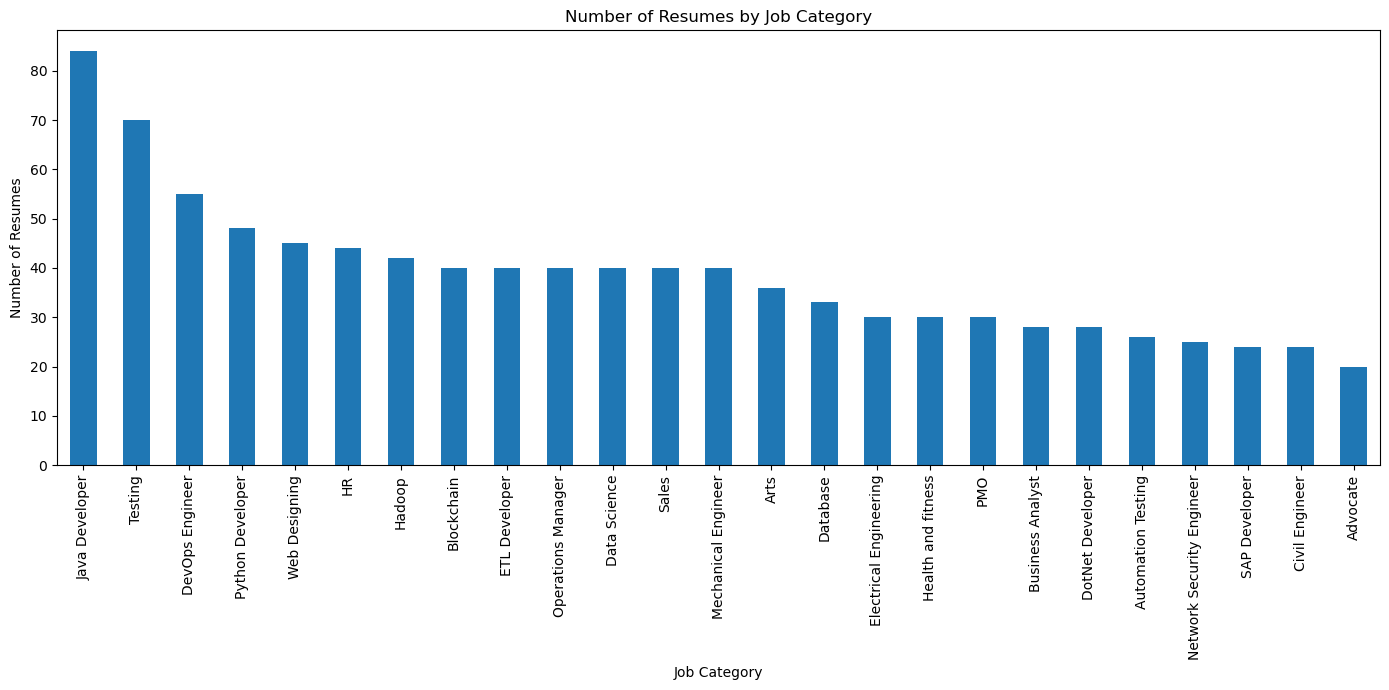

In [16]:
plt.figure(figsize=(14, 7))

df["Category"].value_counts().plot(kind="bar")

plt.title("Number of Resumes by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [17]:
df["resume_length"] = df["Resume"].str.len()

In [18]:
df[["Category", "resume_length"]].head()

,Category,resume_length
0,Data Science,4746
1,Data Science,1268
2,Data Science,1871
3,Data Science,6995
4,Data Science,452


In [19]:
df["resume_length"].describe()

count      962.000000
mean      3160.323285
std       2886.505367
min        142.000000
25%       1217.250000
50%       2355.000000
75%       4073.750000
max      14816.000000
Name: resume_length, dtype: float64

In [20]:
print("Minimum resume length:", df["resume_length"].min())
print("Maximum resume length:", df["resume_length"].max())
print("Average resume length:", df["resume_length"].mean())

Minimum resume length: 142
Maximum resume length: 14816
Average resume length: 3160.3232848232847


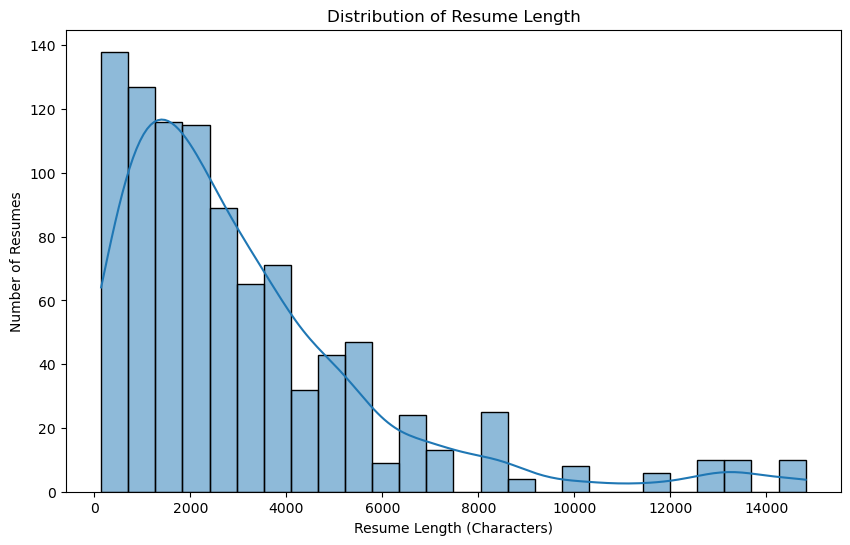

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(df["resume_length"], kde=True)

plt.title("Distribution of Resume Length")
plt.xlabel("Resume Length (Characters)")
plt.ylabel("Number of Resumes")

plt.show()

In [22]:
category_length = (
    df.groupby("Category")["resume_length"]
      .mean()
      .sort_values(ascending=False)
)

category_length

Category
Operations Manager           12025.250000
PMO                           5414.333333
Business Analyst              4944.428571
Network Security Engineer     4168.600000
Automation Testing            4163.769231
DevOps Engineer               3996.745455
Database                      3873.909091
SAP Developer                 3769.000000
ETL Developer                 3557.600000
Hadoop                        3551.428571
Data Science                  3212.100000
Mechanical Engineer           3142.200000
Civil Engineer                3069.166667
Web Designing                 2980.800000
DotNet Developer              2786.571429
Electrical Engineering        2545.000000
Arts                          2293.500000
Blockchain                    2290.200000
Health and fitness            1886.666667
Testing                       1869.428571
Python Developer              1791.000000
Sales                         1670.200000
Java Developer                1629.428571
Advocate                 

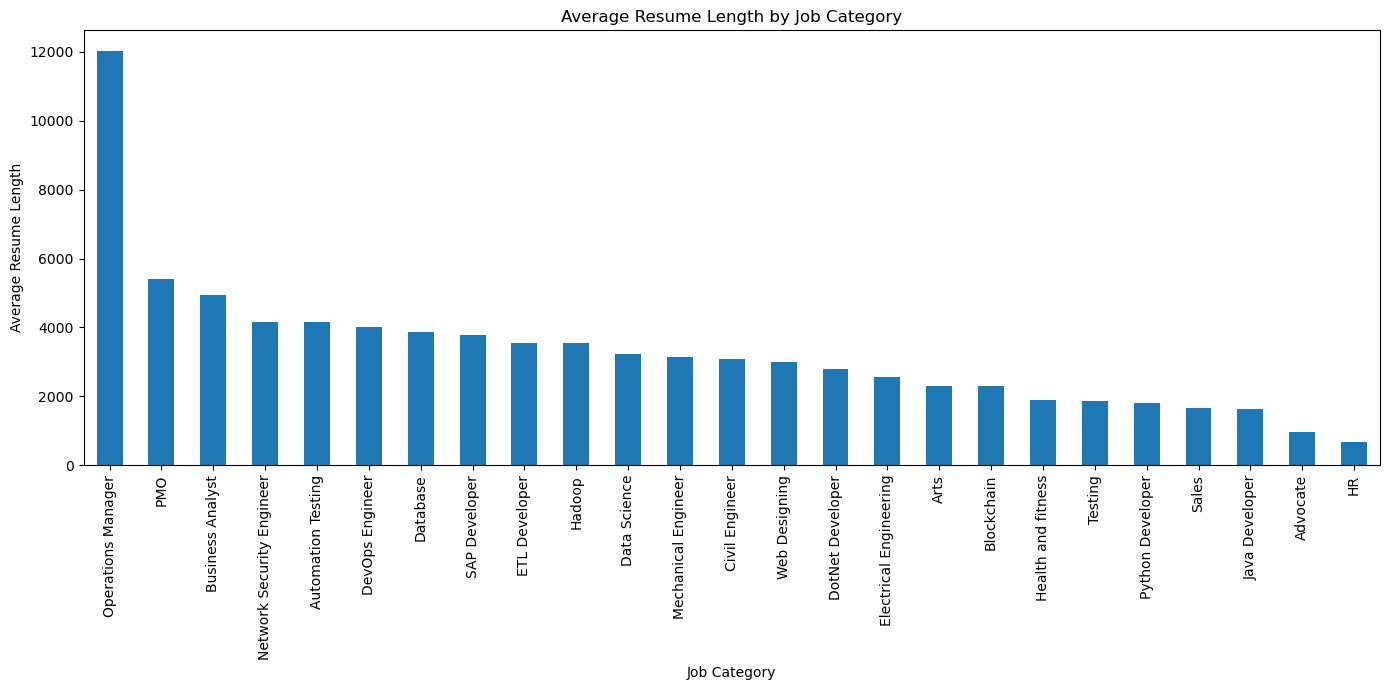

In [23]:
plt.figure(figsize=(14, 7))

category_length.plot(kind="bar")

plt.title("Average Resume Length by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Average Resume Length")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [24]:
print(df["Resume"].iloc[0])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

In [25]:
df[["Category", "Resume"]].head(10)

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
5,Data Science,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...
9,Data Science,Expertise â Data and Quantitative Analysis â...


In [26]:
(df["Resume"].str.strip() == "").sum()

np.int64(0)

In [27]:
df["Resume"].duplicated().sum()

np.int64(795)

In [28]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique categories:", df["Category"].nunique())

Rows: 962
Columns: 3
Missing values: 0
Duplicate rows: 795
Unique categories: 25


In [29]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [30]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lohar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lohar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lohar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
import pandas as pd

In [32]:
df = pd.read_csv(r"C:\Users\lohar\OneDrive\Documents\DA udemy\AI capstone project\UpdatedResumeDataSet.csv")
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [33]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [34]:
df = df.dropna(subset=["Resume", "Category"]).copy()

In [35]:
df["Resume"] = df["Resume"].astype(str)
df["Category"] = df["Category"].astype(str).str.strip()

In [36]:
df["Resume"] = df["Resume"].str.lower()

In [37]:
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [38]:
df["clean_resume"] = df["Resume"].apply(clean_text)

In [39]:
stop_words = set(stopwords.words("english"))

In [40]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [41]:
df["clean_resume"] = df["clean_resume"].apply(remove_stopwords)

In [42]:
df[["Resume", "clean_resume", "Category"]].head()

,Resume,clean_resume,Category
0,skills * programming languages: python (pandas...,skills programming languages python pandas num...,Data Science
1,education details \r\nmay 2013 to may 2017 b.e...,education details may may b e uit rgpv data sc...,Data Science
2,"areas of interest deep learning, control syste...",areas interest deep learning control system de...,Data Science
3,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...,Data Science
4,"education details \r\n mca ymcaust, faridab...",education details mca ymcaust faridabad haryan...,Data Science


In [43]:
df["tokenized_resume"] = df["clean_resume"].apply(word_tokenize)

In [44]:
df["token_count"] = df["tokenized_resume"].apply(len)

In [45]:
df[["Category", "token_count"]].head()

,Category,token_count
0,Data Science,502
1,Data Science,130
2,Data Science,190
3,Data Science,721
4,Data Science,49


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

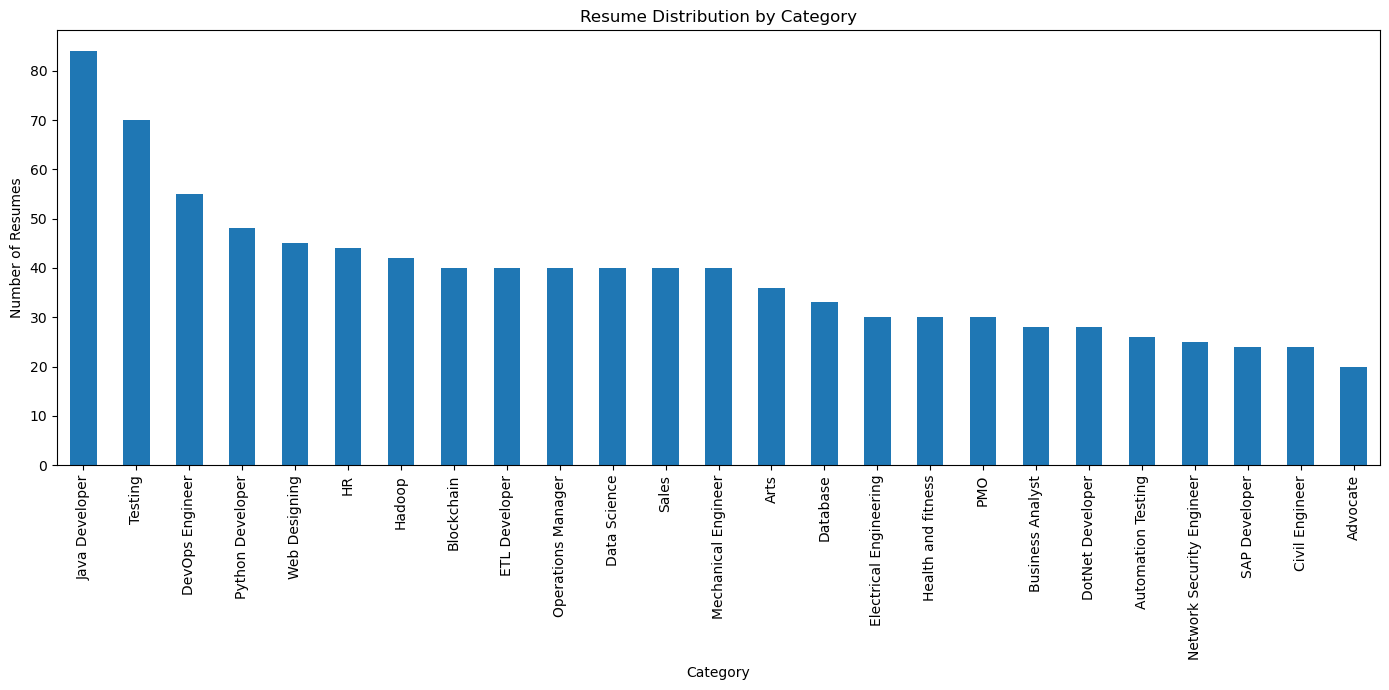

In [47]:
category_counts = df["Category"].value_counts()

plt.figure(figsize=(14, 7))
category_counts.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.title("Resume Distribution by Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

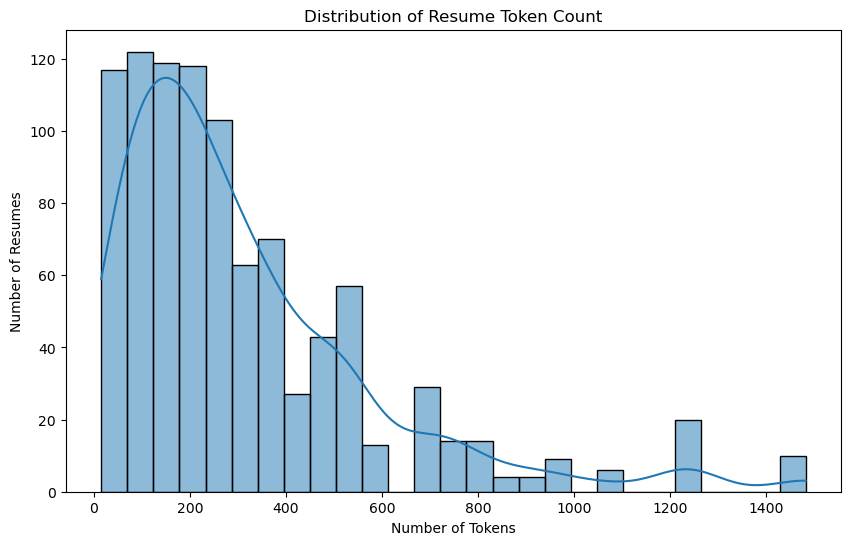

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(df["token_count"], kde=True)
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Resumes")
plt.title("Distribution of Resume Token Count")
plt.show()

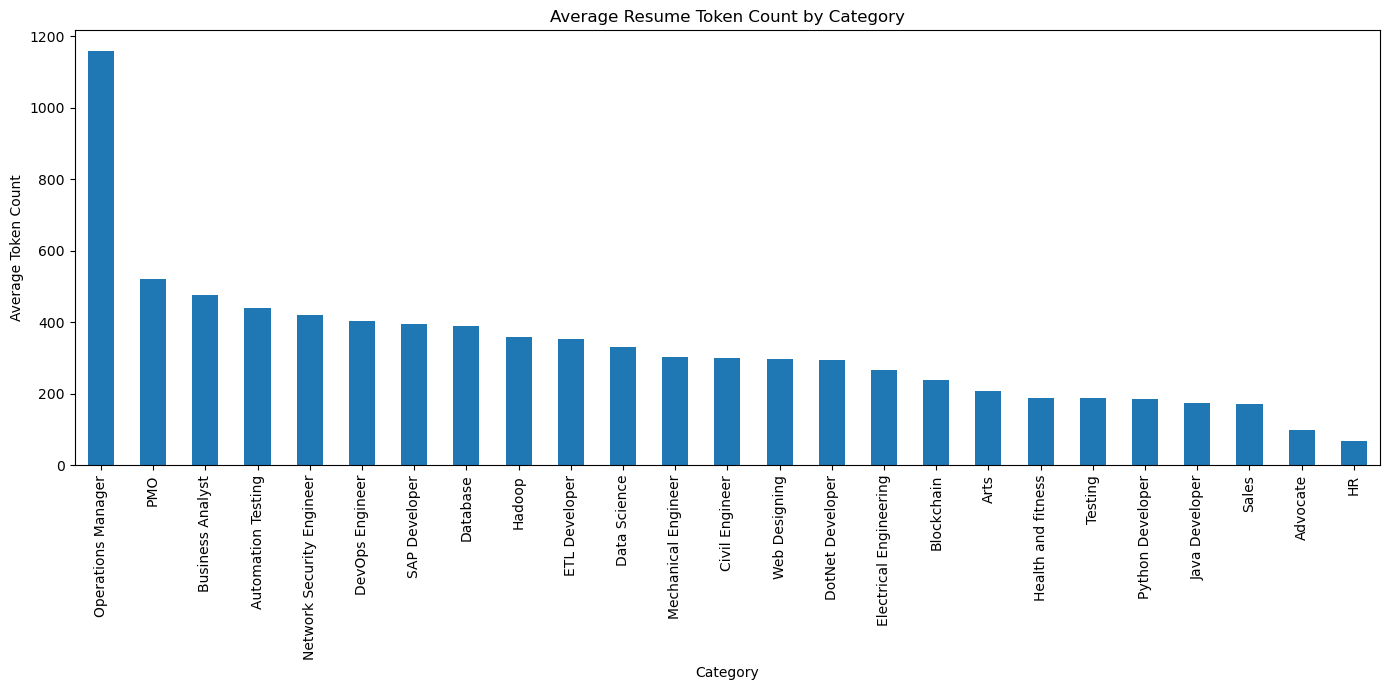

In [49]:
category_tokens = df.groupby("Category")["token_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
category_tokens.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Average Token Count")
plt.title("Average Resume Token Count by Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [50]:
all_words = " ".join(df["clean_resume"]).split()
word_counts = Counter(all_words)

In [51]:
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,exprience,3829
1,company,3578
2,project,3498
3,months,3288
4,description,3122
5,details,3096
6,data,2156
7,management,1999
8,team,1950
9,maharashtra,1449


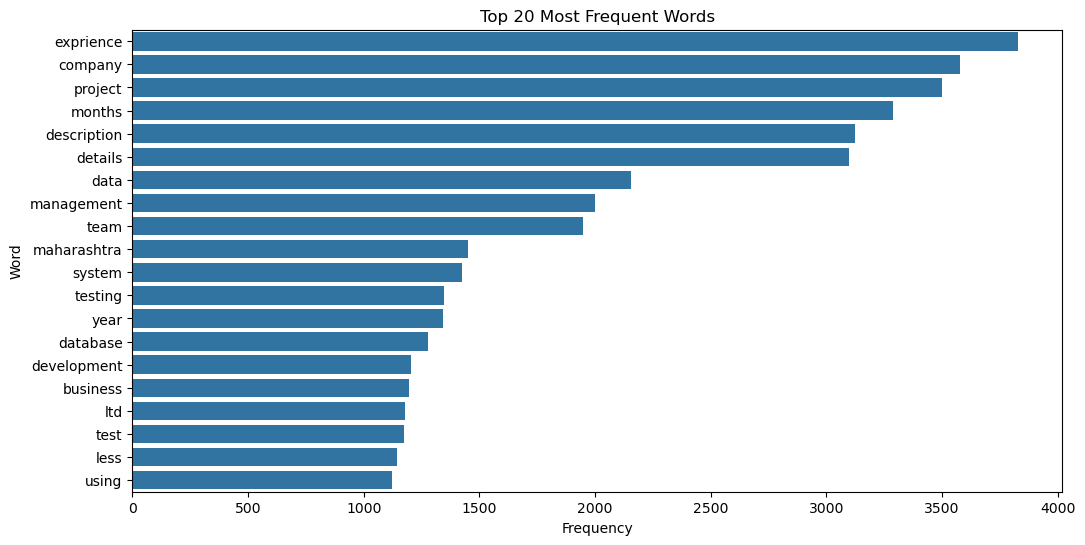

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x="Frequency", y="Word")
plt.title("Top 20 Most Frequent Words")
plt.show()

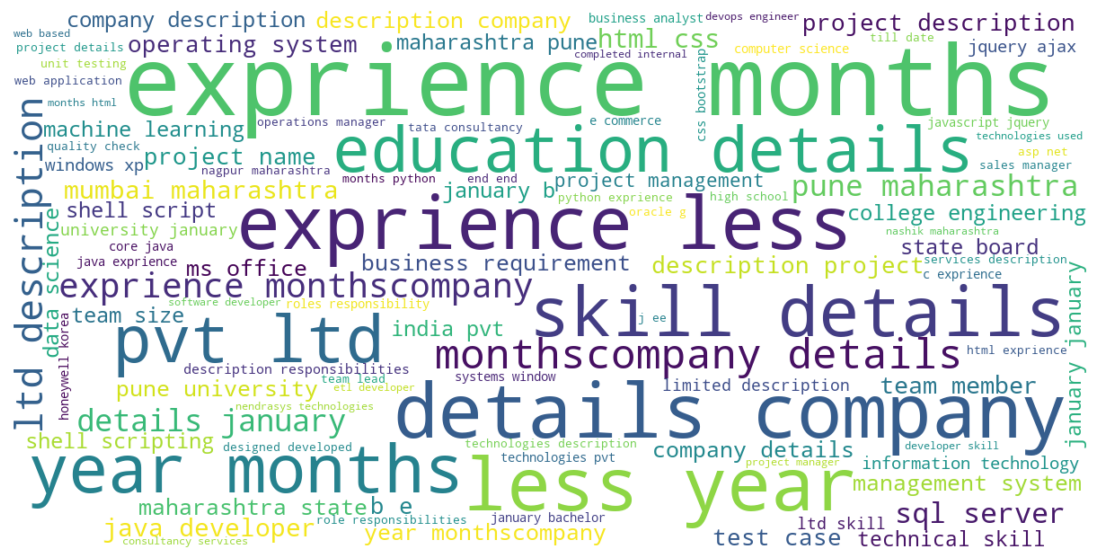

In [53]:
text = " ".join(df["clean_resume"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [54]:
df["resume_length"] = df["Resume"].str.len()
df["clean_resume_length"] = df["clean_resume"].str.len()
df["token_count"] = df["tokenized_resume"].apply(len)

In [55]:
df[["resume_length", "clean_resume_length", "token_count"]].describe()

,resume_length,clean_resume_length,token_count
count,962.000000,962.000000,962.000000
mean,3160.323285,2507.993763,315.969854
std,2886.505367,2265.005414,278.849928
min,142.000000,115.000000,15.000000
25%,1217.250000,995.000000,127.000000
50%,2355.000000,1841.000000,237.000000
75%,4073.750000,3033.000000,405.000000
max,14816.000000,11522.000000,1483.000000


In [56]:
df.groupby("Category")[["resume_length", "clean_resume_length", "token_count"]].mean().sort_values(
    "token_count", ascending=False
)

,resume_length,clean_resume_length,token_count
Category,,,
Operations Manager,12025.250000,9422.250000,1158.500000
PMO,5414.333333,4362.666667,522.000000
Business Analyst,4944.428571,3910.071429,475.214286
Automation Testing,4163.769231,3432.615385,440.461538
Network Security Engineer,4168.600000,3359.600000,420.000000
DevOps Engineer,3996.745455,3175.254545,403.290909
SAP Developer,3769.000000,2989.333333,394.000000
Database,3873.909091,3103.090909,389.000000
Hadoop,3551.428571,2726.285714,359.571429


In [57]:
print("PHASE 2 - DATASET BASELINE")
print("-" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df[["Category", "Resume"]].duplicated().sum())
print("Unique categories:", df["Category"].nunique())

PHASE 2 - DATASET BASELINE
----------------------------------------
Rows: 962
Columns: 7
Missing values: 0
Duplicate rows: 795
Unique categories: 25


In [58]:
duplicate_rows = df[
    df[["Category", "Resume"]].duplicated(keep=False)
].sort_values(
    by=["Category", "Resume"]
)

duplicate_rows[["Category", "Resume"]].head(10)

,Category,Resume
85,Advocate,"education details \r\n b.com, ll.b., univers..."
95,Advocate,"education details \r\n b.com, ll.b., univers..."
86,Advocate,education details \r\n llb. dibrugarh univer...
96,Advocate,education details \r\n llb. dibrugarh univer...
87,Advocate,education details \r\nnovember 2016 to january...
97,Advocate,education details \r\nnovember 2016 to january...
92,Advocate,good grasping quality and skillful work educat...
102,Advocate,good grasping quality and skillful work educat...
89,Advocate,qualification: introduction to computer extrae...
99,Advocate,qualification: introduction to computer extrae...


In [59]:
print(
    "Duplicate resume texts:",
    df["Resume"].duplicated().sum()
)

Duplicate resume texts: 795


In [60]:
df[
    df["Resume"].duplicated(keep=False)
][["Category", "Resume"]].head(10)

,Category,Resume
1,Data Science,education details \r\nmay 2013 to may 2017 b.e...
2,Data Science,"areas of interest deep learning, control syste..."
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,Data Science,"education details \r\n mca ymcaust, faridab..."
5,Data Science,"skills c basics, iot, python, matlab, data sci..."
6,Data Science,skills â¢ python â¢ tableau â¢ data visuali...
7,Data Science,education details \r\n b.tech rayat and bahr...
8,Data Science,personal skills â¢ ability to quickly grasp t...
9,Data Science,expertise â data and quantitative analysis â...
10,Data Science,skills * programming languages: python (pandas...


In [61]:
duplicate_category_check = (
    df.groupby("Resume")["Category"]
    .nunique()
    .sort_values(ascending=False)
)

duplicate_category_check.head(10)

Resume
* excellent grasping power in learning new concepts and technology. * highly motivated team player with strong work ethics, committed to hard work. * ability to work and co-ordinate in a team effectively. * enthusiastic self-starter and team player. * quick and independent learner.education details \r\njanuary 2014 bachelor of technology information technology branch  bput university\r\njanuary 2010 diploma engineering brahmapur, orissa u.c.p engineering school\r\nsoftware testing & automation engineer \r\n\r\nsoftware testing & automation engineer - tech mahindra\r\nskill details \r\ncompany details \r\ncompany - tech mahindra\r\ndescription - india\r\nduration       oct 2017- till date\r\n\r\nproject description\r\nbt group plc (trading as bt and formerly british telecom) is a british multinational telecommunications holding company with head offices in london, united kingdom. i worked for air logistics program under the banner of british telecom. this project handles all the 

In [62]:
conflicting_resumes = duplicate_category_check[
    duplicate_category_check > 1
]

print(
    "Resumes appearing under multiple categories:",
    len(conflicting_resumes)
)

Resumes appearing under multiple categories: 0


In [63]:
if len(conflicting_resumes) > 0:
    print("Conflicting resumes found:")
    
    print(
        df[
            df["Resume"].isin(conflicting_resumes.index)
        ][["Category", "Resume"]]
    )
else:
    print("No resume appears under multiple categories.")

No resume appears under multiple categories.


In [64]:
df_clean = df.drop_duplicates(
    subset=["Category", "Resume"]
).copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 962
Rows after removing duplicates: 167
Rows removed: 795


In [65]:
print(
    "Remaining duplicate records:",
    df_clean[["Category", "Resume"]].duplicated().sum()
)

print(
    "Remaining duplicate resumes:",
    df_clean["Resume"].duplicated().sum()
)

Remaining duplicate records: 0
Remaining duplicate resumes: 0


In [66]:
print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (167, 7)


In [67]:
category_counts_clean = (
    df_clean["Category"]
    .value_counts()
)

category_counts_clean

Category
Java Developer               13
Data Science                 11
Database                     11
Advocate                     10
HR                           10
DotNet Developer              7
Hadoop                        7
DevOps Engineer               7
Automation Testing            7
Testing                       7
Civil Engineer                6
Business Analyst              6
SAP Developer                 6
Health and fitness            6
Python Developer              6
Arts                          6
Electrical Engineering        5
Sales                         5
Network Security Engineer     5
Mechanical Engineer           5
ETL Developer                 5
Blockchain                    5
Operations Manager            4
Web Designing                 4
PMO                           3
Name: count, dtype: int64

In [68]:
category_percentage = (
    df_clean["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

Category
Java Developer               7.78
Data Science                 6.59
Database                     6.59
Advocate                     5.99
HR                           5.99
DotNet Developer             4.19
Hadoop                       4.19
DevOps Engineer              4.19
Automation Testing           4.19
Testing                      4.19
Civil Engineer               3.59
Business Analyst             3.59
SAP Developer                3.59
Health and fitness           3.59
Python Developer             3.59
Arts                         3.59
Electrical Engineering       2.99
Sales                        2.99
Network Security Engineer    2.99
Mechanical Engineer          2.99
ETL Developer                2.99
Blockchain                   2.99
Operations Manager           2.40
Web Designing                2.40
PMO                          1.80
Name: proportion, dtype: float64

In [69]:
category_summary = pd.DataFrame({
    "Resume Count": category_counts_clean,
    "Percentage": category_percentage
})

category_summary

,Resume Count,Percentage
Category,,
Java Developer,13,7.78
Data Science,11,6.59
Database,11,6.59
Advocate,10,5.99
HR,10,5.99
DotNet Developer,7,4.19
Hadoop,7,4.19
DevOps Engineer,7,4.19
Automation Testing,7,4.19


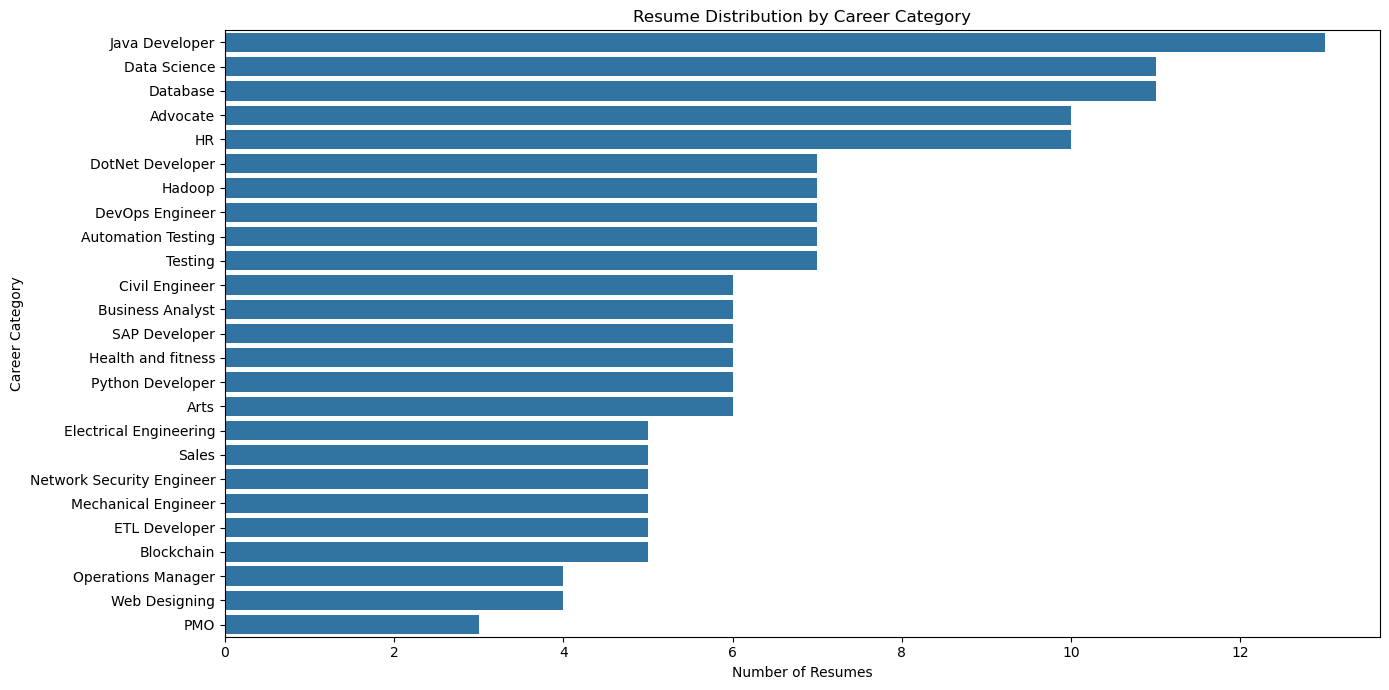

In [70]:
plt.figure(figsize=(14, 7))

sns.barplot(
    x=category_counts_clean.values,
    y=category_counts_clean.index
)

plt.title("Resume Distribution by Career Category")
plt.xlabel("Number of Resumes")
plt.ylabel("Career Category")

plt.tight_layout()
plt.show()

In [71]:
largest_category = category_counts_clean.idxmax()
largest_count = category_counts_clean.max()

smallest_category = category_counts_clean.idxmin()
smallest_count = category_counts_clean.min()

print("Largest category:", largest_category)
print("Number of resumes:", largest_count)

print()

print("Smallest category:", smallest_category)
print("Number of resumes:", smallest_count)

Largest category: Java Developer
Number of resumes: 13

Smallest category: PMO
Number of resumes: 3


In [72]:
df_clean["resume_char_count"] = (
    df_clean["Resume"].str.len()
)

In [73]:
df_clean["resume_char_count"].describe()

count      167.000000
mean      2990.688623
std       2641.664834
min        142.000000
25%       1041.000000
50%       2367.000000
75%       4019.500000
max      14816.000000
Name: resume_char_count, dtype: float64

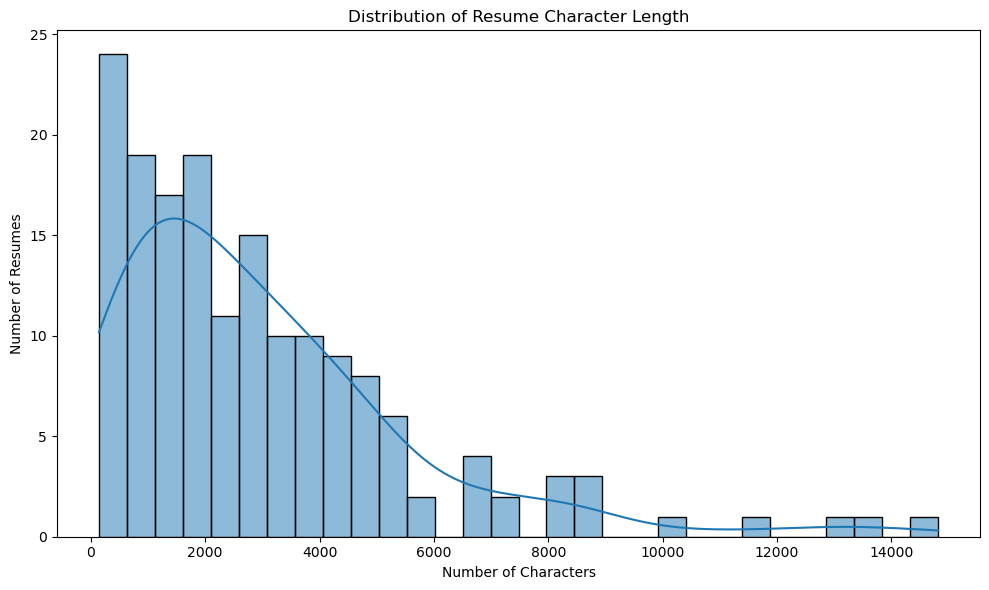

In [74]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["resume_char_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Resume Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Resumes")

plt.tight_layout()
plt.show()

In [75]:
category_length = (
    df_clean.groupby("Category")["resume_char_count"]
    .mean()
    .sort_values(ascending=False)
)

category_length

Category
Operations Manager           12025.250000
PMO                           5414.333333
DevOps Engineer               4573.285714
Business Analyst              4366.666667
Network Security Engineer     4168.600000
Database                      3873.909091
Automation Testing            3797.142857
SAP Developer                 3769.000000
ETL Developer                 3557.600000
Hadoop                        3551.428571
Data Science                  3352.454545
Mechanical Engineer           3142.200000
Civil Engineer                3069.166667
Web Designing                 2826.000000
DotNet Developer              2786.571429
Electrical Engineering        2545.000000
Arts                          2293.500000
Blockchain                    2290.200000
Health and fitness            1886.666667
Testing                       1869.428571
Python Developer              1791.000000
Sales                         1670.200000
Java Developer                1659.692308
Advocate                 

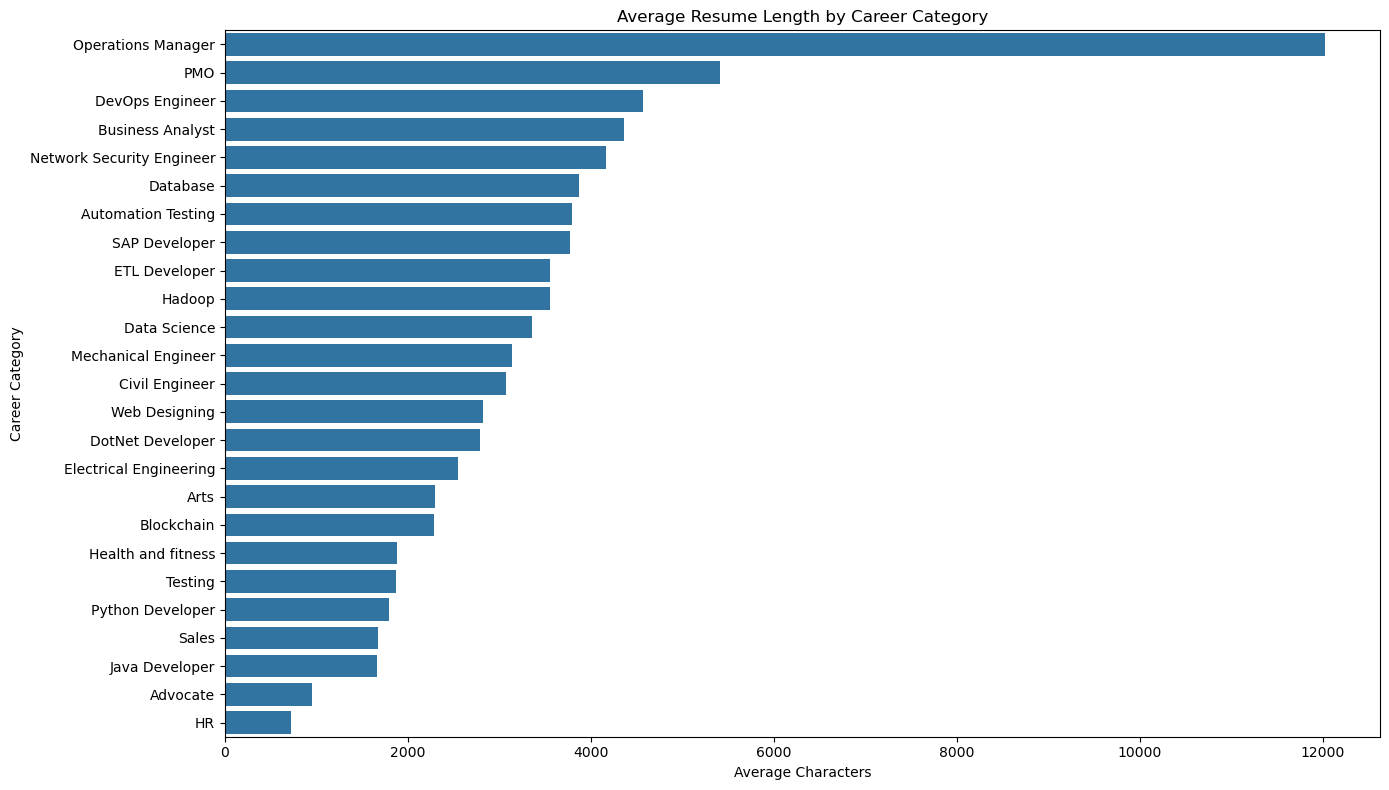

In [76]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x=category_length.values,
    y=category_length.index
)

plt.title("Average Resume Length by Career Category")
plt.xlabel("Average Characters")
plt.ylabel("Career Category")

plt.tight_layout()
plt.show()

In [77]:
short_resumes = df_clean[
    df_clean["resume_char_count"] < 100
]

print(
    "Resumes shorter than 100 characters:",
    len(short_resumes)
)

Resumes shorter than 100 characters: 0


In [78]:
short_resumes[
    ["Category", "resume_char_count", "Resume"]
]

,Category,resume_char_count,Resume


In [79]:
df_clean.nlargest(
    10,
    "resume_char_count"
)[
    ["Category", "resume_char_count"]
]

,Category,resume_char_count
514,Operations Manager,14816
513,Operations Manager,13479
511,Operations Manager,12919
406,Business Analyst,11587
185,Mechanical Engineer,10086
432,SAP Developer,8700
829,DotNet Developer,8527
106,Arts,8514
602,DevOps Engineer,8291
7,Data Science,8192


In [80]:
encoding_pattern = r"â|Ã|Â|ð"

encoding_issue_count = (
    df_clean["Resume"]
    .str.contains(
        encoding_pattern,
        regex=True,
        na=False
    )
    .sum()
)

print(
    "Resumes with possible encoding artifacts:",
    encoding_issue_count
)

Resumes with possible encoding artifacts: 126


In [81]:
import re

def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )
    
    # Keep letters and spaces
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )
    
    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    
    return text.strip()

In [82]:
df_clean["clean_resume"] = (
    df_clean["Resume"]
    .apply(clean_text)
)

In [83]:
df_clean[
    ["Category", "Resume", "clean_resume"]
].head()

,Category,Resume,clean_resume
0,Data Science,skills * programming languages: python (pandas...,skills programming languages python pandas num...
1,Data Science,education details \r\nmay 2013 to may 2017 b.e...,education details may to may b e uit rgpv data...
2,Data Science,"areas of interest deep learning, control syste...",areas of interest deep learning control system...
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"education details \r\n mca ymcaust, faridab...",education details mca ymcaust faridabad haryan...


In [84]:
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words("english")
)

In [85]:
def remove_stopwords(text):
    words = text.split()
    
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [86]:
df_clean["clean_resume"] = (
    df_clean["clean_resume"]
    .apply(remove_stopwords)
)

In [87]:
from nltk.tokenize import word_tokenize

df_clean["tokenized_resume"] = (
    df_clean["clean_resume"]
    .apply(word_tokenize)
)

In [88]:
df_clean["token_count"].describe()

count     167.000000
mean      301.508982
std       259.176427
min        15.000000
25%       111.500000
50%       242.000000
75%       407.000000
max      1483.000000
Name: token_count, dtype: float64

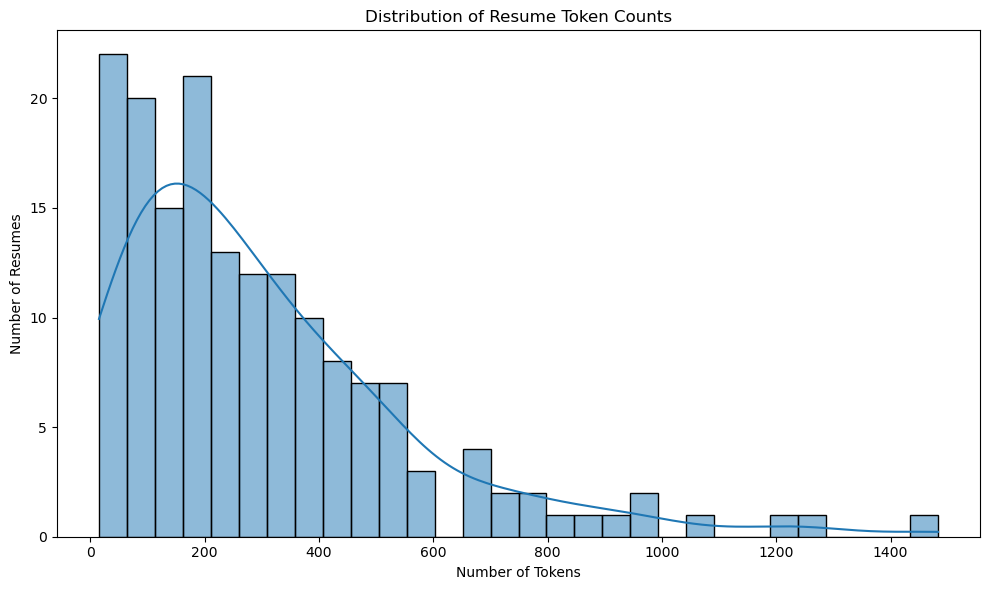

In [89]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["token_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Resume Token Counts")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Resumes")

plt.tight_layout()
plt.show()

In [90]:
avg_tokens_category = (
    df_clean.groupby("Category")["token_count"]
    .mean()
    .sort_values(ascending=False)
)

avg_tokens_category

Category
Operations Manager           1158.500000
PMO                           522.000000
DevOps Engineer               473.857143
Business Analyst              421.833333
Network Security Engineer     420.000000
Automation Testing            398.857143
SAP Developer                 394.000000
Database                      389.000000
Hadoop                        359.571429
ETL Developer                 353.400000
Data Science                  346.090909
Mechanical Engineer           302.200000
Civil Engineer                300.000000
DotNet Developer              293.000000
Web Designing                 288.250000
Electrical Engineering        266.000000
Blockchain                    238.000000
Arts                          207.500000
Health and fitness            187.666667
Testing                       186.714286
Python Developer              184.500000
Java Developer                176.230769
Sales                         170.800000
Advocate                       97.700000
HR     

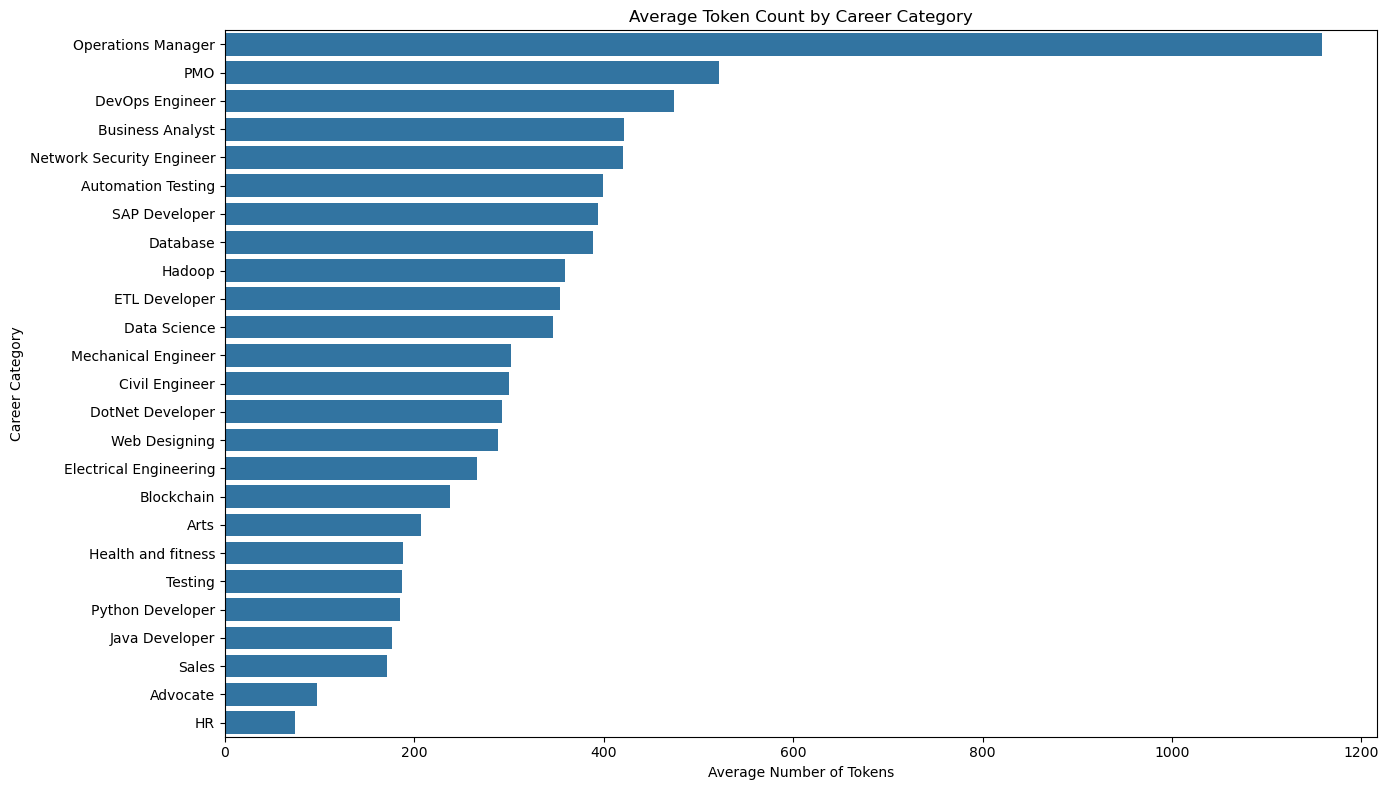

In [91]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x=avg_tokens_category.values,
    y=avg_tokens_category.index
)

plt.title("Average Token Count by Career Category")
plt.xlabel("Average Number of Tokens")
plt.ylabel("Career Category")

plt.tight_layout()
plt.show()

In [92]:
from collections import Counter

all_words = " ".join(
    df_clean["clean_resume"]
).split()

word_counts = Counter(all_words)

top_words = word_counts.most_common(30)

top_words

[('exprience', 619),
 ('company', 604),
 ('project', 542),
 ('description', 541),
 ('details', 534),
 ('months', 527),
 ('data', 402),
 ('management', 318),
 ('database', 279),
 ('team', 274),
 ('system', 239),
 ('sql', 237),
 ('year', 230),
 ('maharashtra', 228),
 ('testing', 216),
 ('using', 211),
 ('test', 206),
 ('business', 205),
 ('ltd', 201),
 ('less', 200),
 ('skill', 190),
 ('january', 190),
 ('server', 187),
 ('development', 183),
 ('java', 177),
 ('developer', 176),
 ('c', 172),
 ('client', 166),
 ('skills', 162),
 ('engineering', 162)]

In [93]:
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,exprience,619
1,company,604
2,project,542
3,description,541
4,details,534
5,months,527
6,data,402
7,management,318
8,database,279
9,team,274


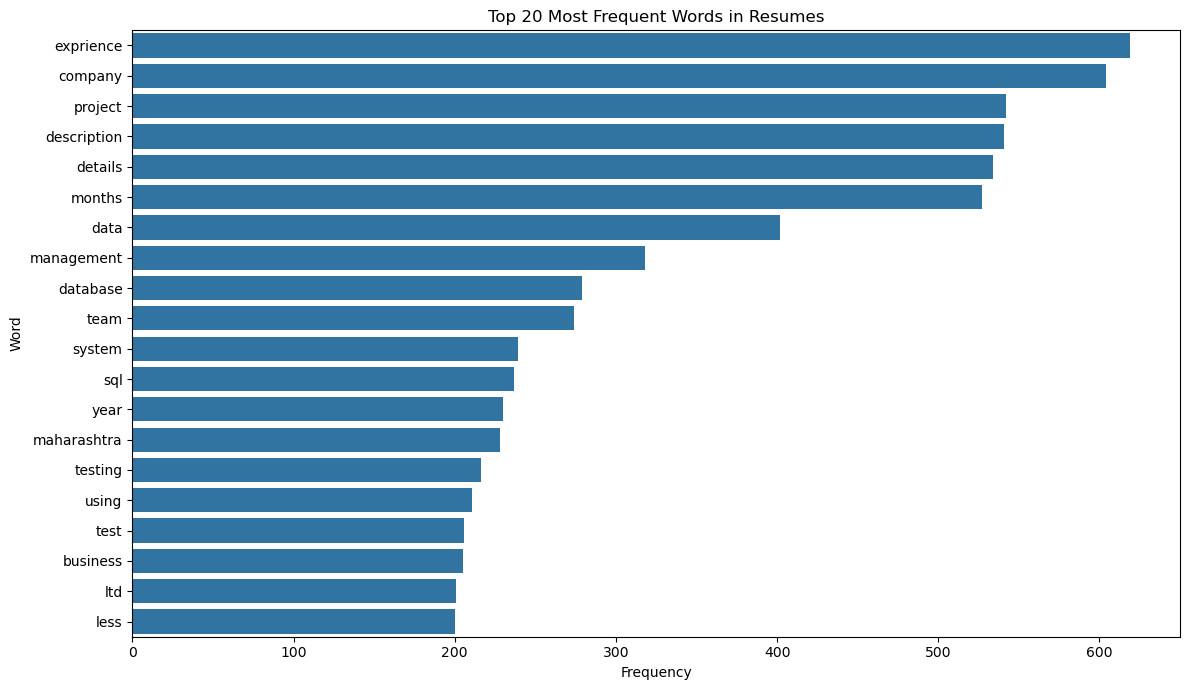

In [94]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_words_df.head(20),
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words in Resumes")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

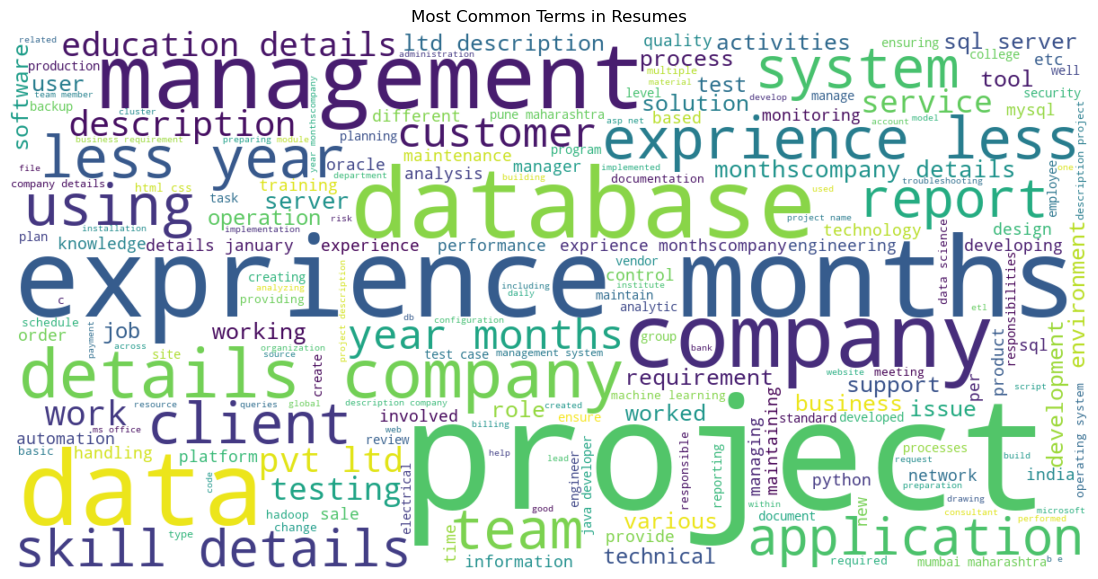

In [95]:
from wordcloud import WordCloud

text = " ".join(
    df_clean["clean_resume"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Most Common Terms in Resumes"
)

plt.show()

In [96]:
print("FINAL DATA QUALITY CHECK")
print("=" * 50)

print("Rows:", df_clean.shape[0])

print(
    "Missing values:",
    df_clean[["Category", "Resume", "clean_resume"]]
    .isnull()
    .sum()
    .sum()
)

print(
    "Duplicate original records:",
    df_clean[["Category", "Resume"]]
    .duplicated()
    .sum()
)

print(
    "Duplicate cleaned resumes:",
    df_clean["clean_resume"]
    .duplicated()
    .sum()
)

print(
    "Empty cleaned resumes:",
    df_clean["clean_resume"]
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Zero-token resumes:",
    (df_clean["token_count"] == 0).sum()
)

print(
    "Unique categories:",
    df_clean["Category"].nunique()
)

FINAL DATA QUALITY CHECK
Rows: 167
Missing values: 0
Duplicate original records: 0
Duplicate cleaned resumes: 1
Empty cleaned resumes: 0
Zero-token resumes: 0
Unique categories: 25


In [97]:
# Check duplicate cleaned resumes
duplicate_cleaned = df_clean["clean_resume"].duplicated().sum()

print("Duplicate cleaned resumes before removal:", duplicate_cleaned)

# Remove duplicate cleaned resumes
df_clean = df_clean.drop_duplicates(
    subset=["clean_resume"],
    keep="first"
).copy()

print(
    "Rows after removing cleaned duplicates:",
    df_clean.shape[0]
)

print(
    "Duplicate cleaned resumes after removal:",
    df_clean["clean_resume"].duplicated().sum()
)

Duplicate cleaned resumes before removal: 1
Rows after removing cleaned duplicates: 166
Duplicate cleaned resumes after removal: 0


In [98]:
final_df = df_clean[
    [
        "Category",
        "Resume",
        "clean_resume",
        "token_count"
    ]
].copy()

In [99]:
final_df.head()

,Category,Resume,clean_resume,token_count
0,Data Science,skills * programming languages: python (pandas...,skills programming languages python pandas num...,502
1,Data Science,education details \r\nmay 2013 to may 2017 b.e...,education details may may b e uit rgpv data sc...,130
2,Data Science,"areas of interest deep learning, control syste...",areas interest deep learning control system de...,190
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...,721
4,Data Science,"education details \r\n mca ymcaust, faridab...",education details mca ymcaust faridabad haryan...,49


In [100]:
from pathlib import Path

output_path = Path("outputs")
output_path.mkdir(
    exist_ok=True
)

final_file = output_path / "resume_cleaned.csv"

final_df.to_csv(
    final_file,
    index=False
)

print("Cleaned dataset saved successfully!")
print("File:", final_file)
print("Shape:", final_df.shape)

Cleaned dataset saved successfully!
File: outputs\resume_cleaned.csv
Shape: (166, 4)


In [101]:
phase3_df = df_clean[
    ["Category", "clean_resume"]
].copy()

print("Dataset shape:", phase3_df.shape)
print(phase3_df.head())

Dataset shape: (166, 2)
       Category                                       clean_resume
0  Data Science  skills programming languages python pandas num...
1  Data Science  education details may may b e uit rgpv data sc...
2  Data Science  areas interest deep learning control system de...
3  Data Science  skills r python sap hana tableau sap hana sql ...
4  Data Science  education details mca ymcaust faridabad haryan...


In [102]:
print("Missing categories:", phase3_df["Category"].isna().sum())
print("Missing resumes:", phase3_df["clean_resume"].isna().sum())
print(
    "Empty resumes:",
    phase3_df["clean_resume"].str.strip().eq("").sum()
)
print(
    "Duplicate records:",
    phase3_df[["Category", "clean_resume"]].duplicated().sum()
)

Missing categories: 0
Missing resumes: 0
Empty resumes: 0
Duplicate records: 0


In [103]:
X = phase3_df["clean_resume"]
y = phase3_df["Category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (166,)
y shape: (166,)


In [104]:
category_counts = y.value_counts()

print(category_counts)
print()
print("Minimum resumes in a category:", category_counts.min())

Category
Java Developer               13
Database                     11
Data Science                 10
Advocate                     10
HR                           10
DotNet Developer              7
Hadoop                        7
DevOps Engineer               7
Automation Testing            7
Testing                       7
Civil Engineer                6
Business Analyst              6
SAP Developer                 6
Health and fitness            6
Python Developer              6
Arts                          6
Electrical Engineering        5
Sales                         5
Network Security Engineer     5
Mechanical Engineer           5
ETL Developer                 5
Blockchain                    5
Operations Manager            4
Web Designing                 4
PMO                           3
Name: count, dtype: int64

Minimum resumes in a category: 3


In [105]:
if category_counts.min() < 2:
    print(
        "Warning: At least one category has fewer than 2 resumes."
    )
else:
    print(
        "All categories have enough samples for stratified splitting."
    )

All categories have enough samples for stratified splitting.


In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 132
Testing samples: 34


In [107]:
print("Training category distribution:")
print(y_train.value_counts())

print("\nTesting category distribution:")
print(y_test.value_counts())

Training category distribution:
Category
Java Developer               10
Database                      9
Data Science                  8
HR                            8
Advocate                      8
Automation Testing            6
DevOps Engineer               6
Civil Engineer                5
Business Analyst              5
Arts                          5
Health and fitness            5
Testing                       5
SAP Developer                 5
DotNet Developer              5
Python Developer              5
Hadoop                        5
Mechanical Engineer           4
Network Security Engineer     4
Sales                         4
ETL Developer                 4
Electrical Engineering        4
Blockchain                    4
Web Designing                 3
Operations Manager            3
PMO                           2
Name: count, dtype: int64

Testing category distribution:
Category
Java Developer               3
Database                     2
HR                           2

In [108]:
train_distribution = (
    y_train.value_counts(normalize=True) * 100
).round(2)

test_distribution = (
    y_test.value_counts(normalize=True) * 100
).round(2)

distribution_check = pd.DataFrame({
    "Train %": train_distribution,
    "Test %": test_distribution
}).fillna(0)

distribution_check

,Train %,Test %
Category,,
Advocate,6.06,5.88
Arts,3.79,2.94
Automation Testing,4.55,2.94
Blockchain,3.03,2.94
Business Analyst,3.79,2.94
Civil Engineer,3.79,2.94
Data Science,6.06,5.88
Database,6.82,5.88
DevOps Engineer,4.55,2.94


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [110]:
tfidf = TfidfVectorizer(
    lowercase=False,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

In [111]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [112]:
X_test_tfidf = tfidf.transform(X_test)

In [113]:
# No TF-IDF refitting on the complete dataset.
# TF-IDF must remain fitted only on X_train.

print("TF-IDF remains fitted only on training data.")

TF-IDF remains fitted only on training data.


In [114]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (132, 5000)
Testing TF-IDF shape: (34, 5000)


In [115]:
feature_names = tfidf.get_feature_names_out()

print("Total TF-IDF features:", len(feature_names))
print()
print("First 30 features:")
print(feature_names[:30])

Total TF-IDF features: 5000

First 30 features:
['ab' 'abad' 'abad co' 'abap' 'abap developer' 'abilities' 'ability'
 'ability learn' 'able' 'able work' 'abstract' 'abstract website'
 'academic' 'academy' 'accenture' 'accept' 'accept challenges'
 'acceptance' 'acceptance test' 'access' 'access data' 'access users'
 'accordance' 'according' 'account' 'accounting' 'accounts' 'accurate'
 'accurately' 'achieve']


In [116]:
sample_features = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

sample_features.iloc[:, :20]

,ab,abad,abad co,abap,abap developer,abilities,ability,ability learn,able,able work,abstract,abstract website,academic,academy,accenture,accept,accept challenges,acceptance,acceptance test,access
0,0.109195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.038825
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [117]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [118]:
label_mapping = pd.DataFrame({
    "Encoded Label": range(
        len(label_encoder.classes_)
    ),
    "Category": label_encoder.classes_
})

label_mapping

,Encoded Label,Category
0,0,Advocate
1,1,Arts
2,2,Automation Testing
3,3,Blockchain
4,4,Business Analyst
5,5,Civil Engineer
6,6,Data Science
7,7,Database
8,8,DevOps Engineer
9,9,DotNet Developer


In [119]:
print(
    "Number of classes:",
    len(label_encoder.classes_)
)

print(
    "Training feature shape:",
    X_train_tfidf.shape
)

print(
    "Testing feature shape:",
    X_test_tfidf.shape
)

print(
    "Training labels:",
    y_train_encoded.shape
)

print(
    "Testing labels:",
    y_test_encoded.shape
)

Number of classes: 25
Training feature shape: (132, 5000)
Testing feature shape: (34, 5000)
Training labels: (132,)
Testing labels: (34,)


In [120]:
import pickle
from pathlib import Path

model_path = Path("models")
model_path.mkdir(exist_ok=True)

In [121]:
with open(
    model_path / "tfidf_vectorizer.pkl",
    "wb"
) as file:
    pickle.dump(tfidf, file)

In [122]:
with open(
    model_path / "label_encoder.pkl",
    "wb"
) as file:
    pickle.dump(label_encoder, file)

In [123]:
print("Phase 3 artifacts saved successfully!")

print(
    "TF-IDF features:",
    X_train_tfidf.shape[1]
)

print(
    "Career categories:",
    len(label_encoder.classes_)
)

Phase 3 artifacts saved successfully!
TF-IDF features: 5000
Career categories: 25


In [124]:
required_objects = [
    "X_train_tfidf",
    "X_test_tfidf",
    "y_train_encoded",
    "y_test_encoded",
    "label_encoder"
]

for obj in required_objects:
    print(obj, ":", "Available" if obj in globals() else "Missing")

X_train_tfidf : Available
X_test_tfidf : Available
y_train_encoded : Available
y_test_encoded : Available
label_encoder : Available


In [125]:
print("TF-IDF vectorizer:", "Available" if "tfidf" in globals() else "Missing")

TF-IDF vectorizer: Available


In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [127]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": MultinomialNB()
}

In [128]:
trained_models = {}

for name, model in models.items():
    model.fit(
        X_train_tfidf,
        y_train_encoded
    )
    
    trained_models[name] = model
    
    print(name, "trained successfully.")

Logistic Regression trained successfully.
Linear SVM trained successfully.
Naive Bayes trained successfully.


In [129]:
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(
        X_test_tfidf
    )
    
    print(name, "predictions generated.")

Logistic Regression predictions generated.
Linear SVM predictions generated.
Naive Bayes predictions generated.


In [130]:
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, y_pred in predictions.items():
    accuracy = accuracy_score(
        y_test_encoded,
        y_pred
    )
    
    accuracy_results[name] = accuracy
    
    print(
        f"{name}: {accuracy:.4f}"
    )

Logistic Regression: 0.9118
Linear SVM: 0.8824
Naive Bayes: 0.3235


In [131]:
from sklearn.metrics import classification_report

for name, y_pred in predictions.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    print(
        classification_report(
            y_test_encoded,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


Logistic Regression
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       1.00      1.00      1.00         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       1.00      1.00      1.00         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
                   Hadoop       1.00    

In [132]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = []

for name, y_pred in predictions.items():
    
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test_encoded,
            y_pred
        ),
        "Precision": precision_score(
            y_test_encoded,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_encoded,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test_encoded,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(model_results)

results_df.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.911765,0.870000,0.90,0.874286
1,Linear SVM,0.882353,0.810000,0.86,0.820952
2,Naive Bayes,0.323529,0.122982,0.20,0.138909


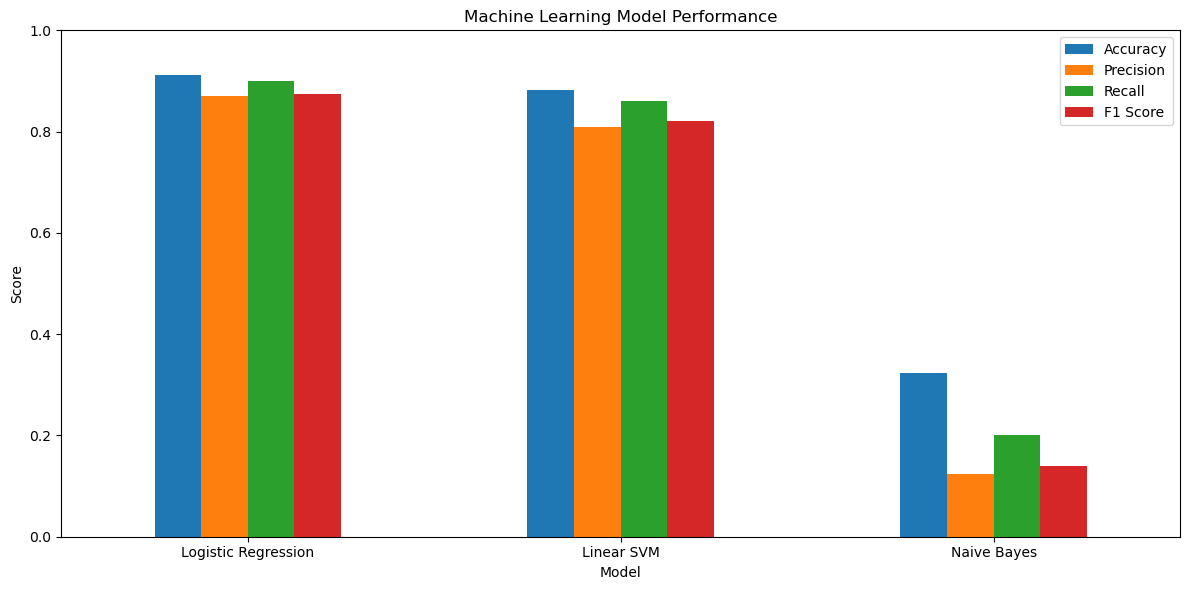

In [133]:
results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [134]:
best_model_name = (
    results_df
    .sort_values("F1 Score", ascending=False)
    .iloc[0]["Model"]
)

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


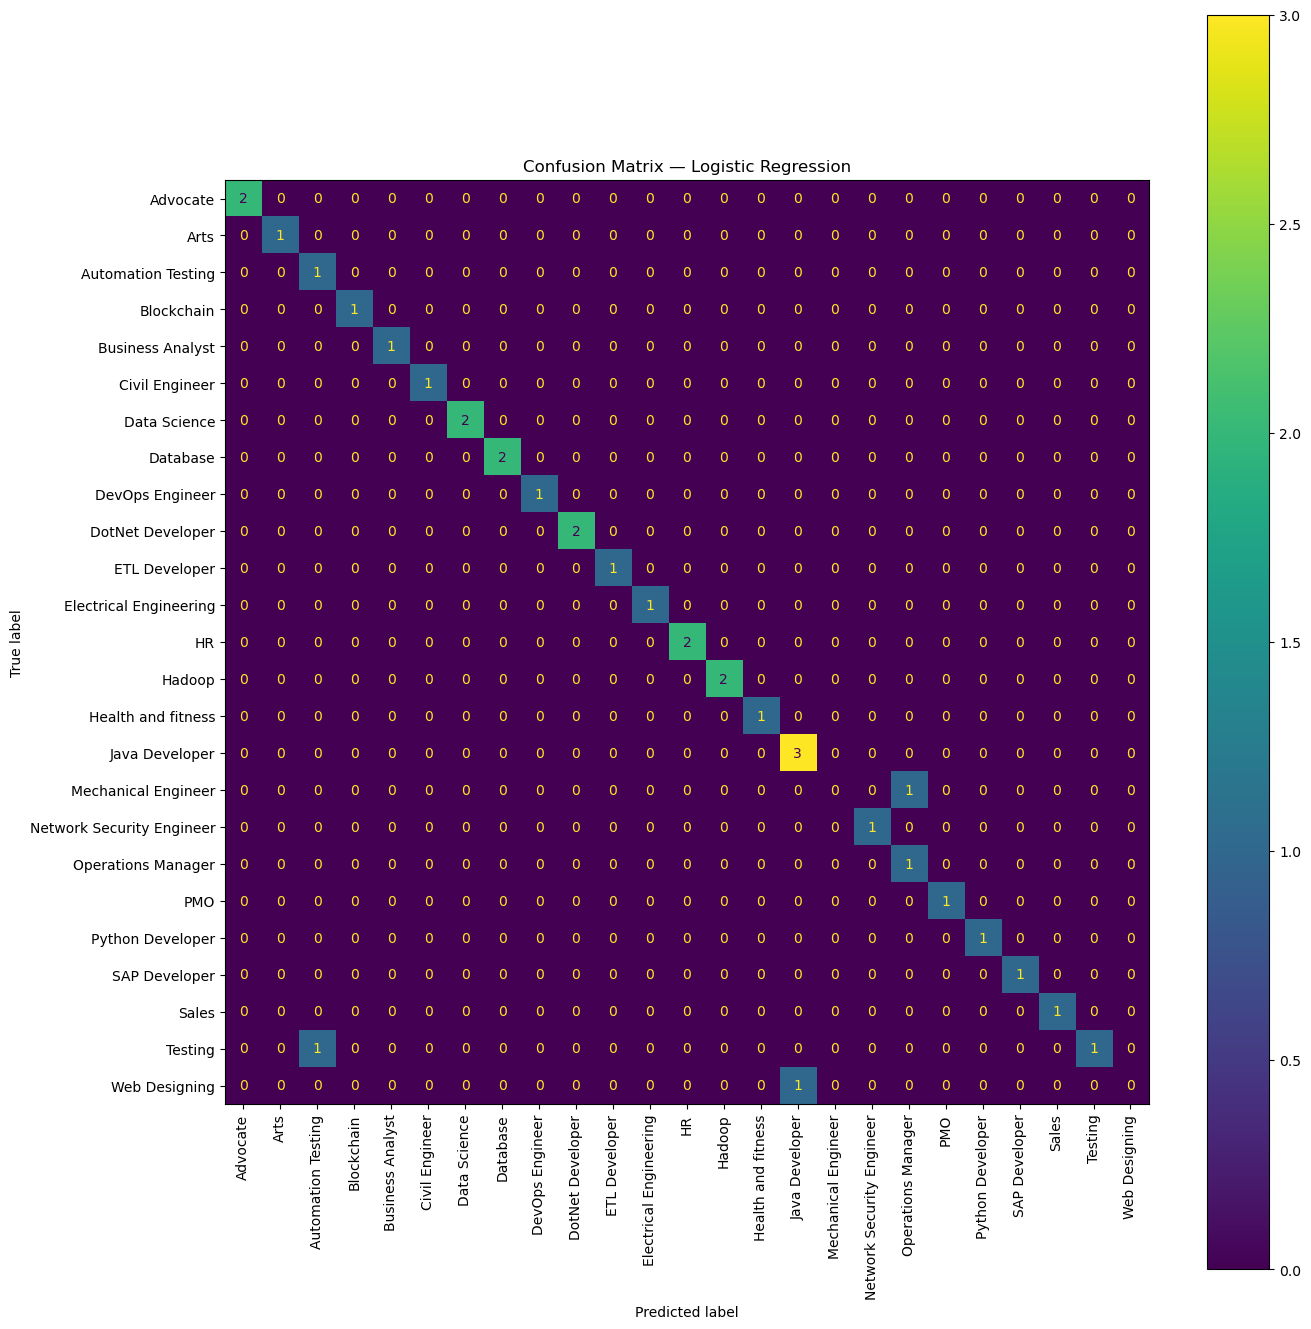

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_predictions = predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test_encoded,
    best_predictions
)

fig, ax = plt.subplots(
    figsize=(14, 14)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.show()

In [136]:
incorrect_predictions = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(
        y_test_encoded
    ),
    
    "Predicted": label_encoder.inverse_transform(
        best_predictions
    )
})

incorrect_predictions = incorrect_predictions[
    incorrect_predictions["Actual"]
    != incorrect_predictions["Predicted"]
]

incorrect_predictions.head(20)

,Actual,Predicted
1,Mechanical Engineer,Operations Manager
17,Web Designing,Java Developer
18,Testing,Automation Testing


In [137]:
import pickle
from pathlib import Path

model_path = Path("models")
model_path.mkdir(exist_ok=True)

with open(
    model_path / "best_resume_classifier.pkl",
    "wb"
) as file:
    pickle.dump(
        best_model,
        file
    )

In [138]:
with open(
    model_path / "best_resume_classifier.pkl",
    "rb"
) as file:
    loaded_model = pickle.load(file)

loaded_predictions = loaded_model.predict(
    X_test_tfidf
)

print(
    "Loaded model accuracy:",
    accuracy_score(
        y_test_encoded,
        loaded_predictions
    )
)

Loaded model accuracy: 0.9117647058823529


In [139]:
import pickle

with open(
    "models/tfidf_vectorizer.pkl",
    "rb"
) as file:
    saved_tfidf = pickle.load(file)

with open(
    "models/label_encoder.pkl",
    "rb"
) as file:
    saved_encoder = pickle.load(file)

with open(
    "models/best_resume_classifier.pkl",
    "rb"
) as file:
    saved_model = pickle.load(file)

print("All components loaded successfully.")

All components loaded successfully.


In [140]:
def prepare_resume(text):
    text = str(text).lower()
    
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )
    
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )
    
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    
    words = text.split()
    
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words).strip()

In [141]:
career_recommendations = {

    "Data Science": [
        "Data Scientist",
        "Machine Learning Engineer",
        "Data Analyst"
    ],

    "Python Developer": [
        "Python Developer",
        "Backend Developer",
        "Software Developer"
    ],

    "Java Developer": [
        "Java Developer",
        "Backend Developer",
        "Software Engineer"
    ],

    "Web Designing": [
        "Web Designer",
        "Frontend Developer",
        "UI Developer"
    ],

    "DevOps Engineer": [
        "DevOps Engineer",
        "Cloud Engineer",
        "Site Reliability Engineer"
    ],

    "Database": [
        "Database Administrator",
        "Database Developer",
        "SQL Developer"
    ],

    "Business Analyst": [
        "Business Analyst",
        "Business Intelligence Analyst",
        "Data Analyst"
    ],

    "HR": [
        "HR Analyst",
        "HR Specialist",
        "Talent Acquisition Specialist"
    ],

    "Sales": [
        "Sales Analyst",
        "Sales Executive",
        "Business Development Executive"
    ],

    "Testing": [
        "QA Tester",
        "Software Test Engineer",
        "QA Analyst"
    ],

    "Automation Testing": [
        "Automation Test Engineer",
        "QA Automation Engineer",
        "SDET"
    ],

    "ETL Developer": [
        "ETL Developer",
        "Data Integration Developer",
        "Data Engineer"
    ],

    "Hadoop": [
        "Hadoop Developer",
        "Big Data Developer",
        "Data Engineer"
    ],

    "SAP Developer": [
        "SAP Developer",
        "SAP Technical Consultant",
        "SAP Analyst"
    ],

    "Network Security Engineer": [
        "Network Security Engineer",
        "Cybersecurity Analyst",
        "Security Engineer"
    ],

    "Blockchain": [
        "Blockchain Developer",
        "Web3 Developer",
        "Blockchain Engineer"
    ],

    "Mechanical Engineer": [
        "Mechanical Engineer",
        "Design Engineer",
        "Manufacturing Engineer"
    ],

    "Civil Engineer": [
        "Civil Engineer",
        "Site Engineer",
        "Structural Engineer"
    ],

    "Electrical Engineering": [
        "Electrical Engineer",
        "Electrical Design Engineer",
        "Power Systems Engineer"
    ],

    "Operations Manager": [
        "Operations Manager",
        "Operations Analyst",
        "Business Operations Analyst"
    ],

    "PMO": [
        "PMO Analyst",
        "Project Coordinator",
        "Project Management Specialist"
    ],

    "Health and fitness": [
        "Fitness Trainer",
        "Health Coach",
        "Fitness Consultant"
    ],

    "Arts": [
        "Creative Designer",
        "Content Designer",
        "Visual Designer"
    ],

    "Advocate": [
        "Legal Associate",
        "Legal Analyst",
        "Legal Consultant"
    ]
}

In [142]:
def get_recommendations(category):

    return career_recommendations.get(
        category,
        [
            category,
            f"{category} Specialist",
            f"{category} Analyst"
        ]
    )

In [143]:
def predict_career(resume_text):

    cleaned_text = prepare_resume(
        resume_text
    )

    if not cleaned_text:
        raise ValueError(
            "Resume does not contain enough usable text."
        )

    resume_vector = saved_tfidf.transform(
        [cleaned_text]
    )

    prediction = saved_model.predict(
        resume_vector
    )

    category = saved_encoder.inverse_transform(
        prediction
    )[0]

    recommendations = get_recommendations(
        category
    )

    return category, recommendations

In [144]:
test_resume = """
Data analyst with experience in Python, SQL, Power BI,
Excel, data visualization, dashboards and machine learning.
Experienced in cleaning datasets, analyzing business data,
creating reports and generating insights.
"""

In [145]:
category, recommendations = predict_career(
    test_resume
)

print("Predicted Career Category:")
print(category)

print("\nRecommended Career Roles:")

for role in recommendations:
    print("-", role)

Predicted Career Category:
Data Science

Recommended Career Roles:
- Data Scientist
- Machine Learning Engineer
- Data Analyst


In [146]:
def get_prediction_confidence(model, vector):

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(vector)
        return probabilities.max()

    if hasattr(model, "decision_function"):
        scores = model.decision_function(vector)
        scores = np.asarray(scores)

        if scores.ndim == 1:
            scores = np.column_stack(
                [-scores, scores]
            )

        exp_scores = np.exp(
            scores - scores.max(axis=1, keepdims=True)
        )

        probabilities = (
            exp_scores /
            exp_scores.sum(
                axis=1,
                keepdims=True
            )
        )

        return probabilities.max()

    return None

In [147]:
def predict_career(resume_text):

    cleaned_text = prepare_resume(
        resume_text
    )

    if not cleaned_text:
        raise ValueError(
            "Resume does not contain enough usable text."
        )

    resume_vector = saved_tfidf.transform(
        [cleaned_text]
    )

    prediction = saved_model.predict(
        resume_vector
    )

    category = saved_encoder.inverse_transform(
        prediction
    )[0]

    confidence = get_prediction_confidence(
        saved_model,
        resume_vector
    )

    recommendations = get_recommendations(
        category
    )

    return {
        "category": category,
        "confidence": confidence,
        "recommendations": recommendations
    }

In [148]:
result = predict_career(
    test_resume
)

print("Predicted Category:")
print(result["category"])

if result["confidence"] is not None:
    print(
        f"\nConfidence: "
        f"{result['confidence']:.2%}"
    )

print("\nRecommended Roles:")

for role in result["recommendations"]:
    print("-", role)

Predicted Category:
Data Science

Confidence: 6.89%

Recommended Roles:
- Data Scientist
- Machine Learning Engineer
- Data Analyst


In [149]:
print(
    f"Best Career Match: "
    f"{result['category']}"
)

print(
    "\nSuggested Career Paths:"
)

for i, role in enumerate(
    result["recommendations"],
    start=1
):
    print(f"{i}. {role}")

Best Career Match: Data Science

Suggested Career Paths:
1. Data Scientist
2. Machine Learning Engineer
3. Data Analyst


In [150]:
test_resumes = {

    "Python Resume": """
    Python developer experienced in Django,
    Flask, APIs, SQL and backend development.
    """,

    "Data Resume": """
    Data scientist with Python, machine learning,
    pandas, statistics and data visualization experience.
    """,

    "Testing Resume": """
    QA professional experienced in Selenium,
    automation testing, test cases and software quality.
    """
}

In [151]:
for name, resume in test_resumes.items():

    result = predict_career(resume)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        "Predicted Category:",
        result["category"]
    )

    if result["confidence"] is not None:
        print(
            "Confidence:",
            f"{result['confidence']:.2%}"
        )

    print("Recommended Roles:")

    for role in result["recommendations"]:
        print("-", role)


Python Resume
Predicted Category: Python Developer
Confidence: 7.41%
Recommended Roles:
- Python Developer
- Backend Developer
- Software Developer

Data Resume
Predicted Category: Data Science
Confidence: 8.20%
Recommended Roles:
- Data Scientist
- Machine Learning Engineer
- Data Analyst

Testing Resume
Predicted Category: Automation Testing
Confidence: 7.65%
Recommended Roles:
- Automation Test Engineer
- QA Automation Engineer
- SDET


In [152]:
with open(
    "models/career_recommendations.pkl",
    "wb"
) as file:
    pickle.dump(
        career_recommendations,
        file
    )

print(
    "Recommendation mapping saved successfully."
)

Recommendation mapping saved successfully.


In [153]:
system_components = {
    "Text Preprocessing": "Completed",
    "TF-IDF Vectorization": "Completed",
    "Resume Classifier": best_model_name,
    "Career Category Prediction": "Completed",
    "Career Recommendation": "Completed",
    "Model Serialization": "Completed"
}

pd.DataFrame(
    system_components.items(),
    columns=["Component", "Status"]
)

,Component,Status
0,Text Preprocessing,Completed
1,TF-IDF Vectorization,Completed
2,Resume Classifier,Logistic Regression
3,Career Category Prediction,Completed
4,Career Recommendation,Completed
5,Model Serialization,Completed


In [173]:
# Test the model using an actual unseen test resume

sample_test_resume = X_test.iloc[0]
actual_category = y_test.iloc[0]

# predict_career() returns:
# category, recommendations
predicted_category, recommendations = predict_career(
    sample_test_resume
)

print("Actual Category:")
print(actual_category)

print("\nPredicted Category:")
print(predicted_category)

print("\nRecommended Career Roles:")

for role in recommendations:
    print("-", role)

Actual Category:
Database

Predicted Category:
Database

Recommended Career Roles:
- Database Administrator
- Database Developer
- SQL Developer


In [154]:
!pip install streamlit pypdf

In [155]:
import streamlit as st
import pickle
import re
from pathlib import Path
from pypdf import PdfReader

In [156]:
from pathlib import Path
import pickle

# Jupyter Notebook uses the current working directory
BASE_DIR = Path.cwd()

MODEL_DIR = BASE_DIR / "models"

print("Project folder:", BASE_DIR)
print("Model folder:", MODEL_DIR)

Project folder: C:\Users\lohar
Model folder: C:\Users\lohar\models


In [157]:
print("TF-IDF:", (MODEL_DIR / "tfidf_vectorizer.pkl").exists())
print("Label Encoder:", (MODEL_DIR / "label_encoder.pkl").exists())
print("Best Model:", (MODEL_DIR / "best_resume_classifier.pkl").exists())
print("Recommendations:", (MODEL_DIR / "career_recommendations.pkl").exists())

TF-IDF: True
Label Encoder: True
Best Model: True
Recommendations: True


In [158]:
with open(
    MODEL_DIR / "tfidf_vectorizer.pkl",
    "rb"
) as file:
    tfidf = pickle.load(file)

with open(
    MODEL_DIR / "label_encoder.pkl",
    "rb"
) as file:
    label_encoder = pickle.load(file)

with open(
    MODEL_DIR / "best_resume_classifier.pkl",
    "rb"
) as file:
    model = pickle.load(file)

with open(
    MODEL_DIR / "career_recommendations.pkl",
    "rb"
) as file:
    career_recommendations = pickle.load(file)

print("All Phase 5 components loaded successfully!")

All Phase 5 components loaded successfully!


In [159]:
stop_words = set(
    """
    a an the and or but if then else for
    in on at to from by with of is are was
    were be been being this that these those
    as it its into about
    """.split()
)

In [160]:
def clean_resume(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words).strip()

In [161]:
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words("english")
)

In [162]:
def extract_pdf_text(uploaded_file):

    reader = PdfReader(
        uploaded_file
    )

    text = ""

    for page in reader.pages:

        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

    return text

In [163]:
def predict_career(resume_text):

    cleaned_text = clean_resume(
        resume_text
    )

    if not cleaned_text:
        return None

    resume_vector = tfidf.transform(
        [cleaned_text]
    )

    prediction = model.predict(
        resume_vector
    )

    category = label_encoder.inverse_transform(
        prediction
    )[0]

    recommendations = career_recommendations.get(
        category,
        [
            category,
            f"{category} Specialist",
            f"{category} Analyst"
        ]
    )

    return category, recommendations

In [164]:
st.set_page_config(
    page_title="CareerMatch AI",
    page_icon="🎯",
    layout="wide"
)

2026-08-21 11:43:15.681 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [165]:
st.title("🎯 CareerMatch AI")

st.subheader(
    "AI-Powered Resume Career Recommendation System"
)

st.write(
    """
    CareerMatch AI analyzes your resume and predicts the most relevant
    career category using Natural Language Processing and Machine Learning.
    """
)

2026-08-21 11:43:15.999 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.979 
  command:

    streamlit run C:\Users\lohar\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-21 11:43:16.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:16.989 Thread 'MainThread': mi

In [166]:
st.header("Upload Your Resume")

uploaded_file = st.file_uploader(
    "Upload a PDF resume",
    type=["pdf"]
)

2026-08-21 11:43:16.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.001 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [167]:
resume_text = ""

if uploaded_file is not None:

    resume_text = extract_pdf_text(
        uploaded_file
    )

    if resume_text.strip():

        st.success(
            "Resume uploaded successfully!"
        )

    else:

        st.error(
            "Could not extract text from this PDF."
        )

In [168]:
st.header("Or Paste Resume Text")

manual_text = st.text_area(
    "Paste your resume here",
    height=250
)

2026-08-21 11:43:17.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:17.532 Session state does not function when running a script without `streamlit run`
2026-08-21 11:43

In [169]:
if manual_text.strip():

    final_resume_text = manual_text

elif resume_text.strip():

    final_resume_text = resume_text

else:

    final_resume_text = ""

In [170]:
if st.button(
    "🔍 Analyze Resume",
    use_container_width=True
):

    if not final_resume_text.strip():

        st.warning(
            "Please upload a resume or paste resume text."
        )

    else:

        result = predict_career(
            final_resume_text
        )

        if result is None:

            st.error(
                "The resume does not contain enough usable text."
            )

        else:

            category, recommendations = result

            st.session_state["category"] = category

            st.session_state[
                "recommendations"
            ] = recommendations

2026-08-21 11:43:18.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:18.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:18.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:18.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:18.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-21 11:43:18.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [171]:
if "category" in st.session_state:

    st.divider()

    st.header(
        "🎯 Career Match"
    )

    st.success(
        f"Recommended Career Category: "
        f"{st.session_state['category']}"
    )

    st.subheader(
        "Recommended Career Roles"
    )

    for role in st.session_state[
        "recommendations"
    ]:

        st.write(
            f"• {role}"
        )

2026-08-21 11:43:19.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# Conclusion

CareerMatch AI solves the problem of identifying suitable career paths from resumes by using **NLP and Machine Learning**.

We cleaned and analyzed the resume data, removed duplicate records, and transformed resume text into numerical **TF-IDF features**. We then trained and compared multiple classification models and selected the best-performing model to predict the most relevant career category.

Finally, we built a recommendation layer that converts the predicted category into relevant career roles. The system was also tested on an unseen resume and correctly predicted its **Database** category.

Overall, CareerMatch AI provides an end-to-end solution that converts unstructured resume information into **career category predictions and actionable career recommendations**.